In [194]:
import pandas as pd
import numpy as np

In [195]:
# ============================================
# 1. CARGA DEL DATASET
# ============================================
datos = pd.read_csv("Evaluaciones_Agropecuarias_Municipales_EVA_20251123.csv")

# Descripción de Necesidades de Limpieza

In [196]:
# ============================================
# Información dataset
# ============================================
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206068 entries, 0 to 206067
Data columns (total 17 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   CÓD. 
DEP.                                     206068 non-null  int64  
 1   DEPARTAMENTO                                   206068 non-null  object 
 2   CÓD. MUN.                                      206068 non-null  object 
 3   MUNICIPIO                                      206067 non-null  object 
 4   GRUPO 
DE CULTIVO                              206068 non-null  object 
 5   SUBGRUPO 
DE CULTIVO                           206068 non-null  object 
 6   CULTIVO                                        206068 non-null  object 
 7   DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO  206068 non-null  object 
 8   AÑO                                            206068 non-null  object 
 9   PERIODO                              

In [197]:
#Renombrar nombre Columnas

transf_nombres_col = {
    'CÓD. \nDEP.': 'cod_dep',
    'DEPARTAMENTO': 'departamento',
    'CÓD. MUN.': 'cod_mun',
    'MUNICIPIO': 'municipio',
    'GRUPO \nDE CULTIVO': 'grupo_de_cultivo',
    'SUBGRUPO \nDE CULTIVO': 'subgrupo_de_cultivo',
    'CULTIVO': 'cultivo',
    'DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO': 'desagregacion_o_sistema_productivo',
    'AÑO': 'anio',
    'PERIODO': 'periodo',
    'Área Sembrada\n(ha)': 'area_sembrada_ha',
    'Área Cosechada\n(ha)': 'area_cosechada_ha',
    'Producción\n(t)': 'produccion_t',
    'Rendimiento\n(t/ha)': 'rendimiento_t_ha',
    'ESTADO FISICO PRODUCCION': 'estado_fisico_produccion',
    'NOMBRE \nCIENTIFICO': 'nombre_cientifico',
    'CICLO DE CULTIVO': 'ciclo_de_cultivo'
}

# Aplicar cambio
datos = datos.rename(columns=transf_nombres_col) 

In [198]:
print(datos)

        cod_dep        departamento cod_mun   municipio grupo_de_cultivo  \
0            15              BOYACA  15,114    BUSBANZA       HORTALIZAS   
1            25        CUNDINAMARCA  25,754      SOACHA       HORTALIZAS   
2            25        CUNDINAMARCA  25,214        COTA       HORTALIZAS   
3            54  NORTE DE SANTANDER  54,405  LOS PATIOS       HORTALIZAS   
4            54  NORTE DE SANTANDER  54,518    PAMPLONA       HORTALIZAS   
...         ...                 ...     ...         ...              ...   
206063       25        CUNDINAMARCA  25,436       MANTA       HORTALIZAS   
206064       25        CUNDINAMARCA  25,524       PANDI       HORTALIZAS   
206065       25        CUNDINAMARCA  25,436       MANTA       HORTALIZAS   
206066       25        CUNDINAMARCA  25,807    TIBIRITA       HORTALIZAS   
206067       25        CUNDINAMARCA  25,524       PANDI       HORTALIZAS   

       subgrupo_de_cultivo    cultivo desagregacion_o_sistema_productivo  \
0          

In [199]:
# ============================================
# 1. Valores duplicados
# ============================================

print(f"Valores duplicados: {datos.columns.duplicated().sum()}")

print("No hay valores totalmente duplicados, estos pueden que tengan valores que se repitan, pero no existe una sola fila que esté repetida de manera exacta")

Valores duplicados: 0
No hay valores totalmente duplicados, estos pueden que tengan valores que se repitan, pero no existe una sola fila que esté repetida de manera exacta


### Valores Nulos

In [200]:
# ============================================
# 2. Valores Nulos
# ============================================

print(f"Valores duplicados: {datos.columns.isnull().sum()}")

Valores duplicados: 0


In [ ]:
Columnas_texto = ['cod_dep',
 'departamento',
 'cod_mun',
 'municipio',
 'grupo_de_cultivo',
 'subgrupo_de_cultivo',
 'cultivo',
 'desagregacion_o_sistema_productivo',
 'anio',
 'periodo',
 'area_sembrada_ha',
 'area_cosechada_ha',
 'produccion_t',
 'rendimiento_t_ha',
 'estado_fisico_produccion',
 'nombre_cientifico',
 'ciclo_de_cultivo']

def valores_nulos(df, col):
    """Cuenta NaN + strings vacíos + '0' como missing"""
    s = df[col].astype(str).str.strip()  # quita espacios
    return (s.isna() | s.eq("") | s.eq("0")).sum()

print("Valores faltantes totales (NaN + vacíos + ceros):")
for col in Columnas_texto:
    print(f"{col}: {valores_nulos(datos, col)}")



Valores faltantes totales (NaN + vacíos + ceros):
cod_dep: 0
departamento: 0
cod_mun: 0
municipio: 0
grupo_de_cultivo: 0
subgrupo_de_cultivo: 0
cultivo: 0
desagregacion_o_sistema_productivo: 0
anio: 0
periodo: 0
area_sembrada_ha: 721
area_cosechada_ha: 4362
produccion_t: 3807
rendimiento_t_ha: 0
estado_fisico_produccion: 0
nombre_cientifico: 0
ciclo_de_cultivo: 0


Porcentaje de valores nulos, faltantes, vacios

% area_sembrada_ha = 0.3% 
% area_cosechada_ha = 2.11%
% produccion_t = 1.84%

No representan porcentajes muy altos, por lo que se hace el proceso de la media para reemplazar esos valores nulos, vacios o con ceros. 

Una de las hipotesis pensadas era que en algunos casos las siembras no dieron frutos, entonces, en un 99,70% de las encuestas hechas siempre sembraron, sin embargo, por situaciones la cosecha bajaba 2.11%. Esto puede suceder por agentes externos o error humano al recibir los resultados de las encuestas

### Tipos de datos

In [202]:
print(datos.dtypes)

cod_dep                                 int64
departamento                           object
cod_mun                                object
municipio                              object
grupo_de_cultivo                       object
subgrupo_de_cultivo                    object
cultivo                                object
desagregacion_o_sistema_productivo     object
anio                                   object
periodo                                object
area_sembrada_ha                       object
area_cosechada_ha                      object
produccion_t                           object
rendimiento_t_ha                      float64
estado_fisico_produccion               object
nombre_cientifico                      object
ciclo_de_cultivo                       object
dtype: object


### Valores atipicos

In [258]:
print("Solo se calculan los datos atipicos del rendimiento ya que es nuestra variable de estudio")


col = "rendimiento_t_ha"

print("Estadísticas básicas del rendimiento:")
print("Mínimo:", datos[col].min())
print("Máximo:", datos[col].max())
print("Media:", datos[col].mean())
print("Mediana:", datos[col].median())


Solo se calculan los datos atipicos del rendimiento ya que es nuestra variable de estudio
Estadísticas básicas del rendimiento:
Mínimo: 0.03
Máximo: 246.0
Media: 9.2388196510968
Mediana: 5.0


Nivel de Granularidad
Granularidad actual:

•  	Cada fila representa municipio – cultivo – año – periodo

•	Nivel de detalle: muy alto

•	Para análisis como “top 10 cultivos” o “tendencias por año”, este nivel es suficiente.

•	Para análisis por departamento o país, se requiere agregación.

•	El año y periodo permiten realizar un análisis de los datos de manera semestral ya que se encuentran desagregados: 

periodo -> ej: 2018A, 2018B
Año -> ej: 2,018

A = primer semestre (enero – junio)

B = segundo semestre (julio – diciembre) 

Permite realizar tendencias anuales y semestrales, mensuales no ya que falta desglose -> granularidad

•	Rendimientos anuales por cultivo

•	Rendimientos por departamento

•	Ranking nacional de productividad

•	Es necesario agregar datos para conocer el rendimiento mensual por productos, municipios, departamentos ya que el dataset carece de eso


# Limpieza y Transformación de Datos

### Eliminación de Duplicados

Se verifica que no existe ningún registro (fila) que esté duplicado, pueden existir filas que contengan información en común tales como el municipio, departamento, tipo de cultivo, pero la cantidad de hectáreas cosechadas, sembradas y su productividad son totalmente diferentes. 

In [204]:
def duplicados_por_columna(df):
    """
    Imprime cuántos valores DUPLICADOS (repetidos) tiene cada columna.
    """
    for col in df.columns:
        unicos = df[col].nunique(dropna=False)
        total  = len(df[col])
        dup    = total - unicos
        print(f"{col}: {dup} valores duplicados")

# Uso
duplicados_por_columna(datos)

print("")

print("Este resultado no indica que hayan filas duplicadas sino que dentro de cada columna existen valores que se repiten.\n Es una repetición natural de valores categóricos o numéricos")

cod_dep: 206036 valores duplicados
departamento: 206036 valores duplicados
cod_mun: 204963 valores duplicados
municipio: 205049 valores duplicados
grupo_de_cultivo: 206055 valores duplicados
subgrupo_de_cultivo: 205948 valores duplicados
cultivo: 205845 valores duplicados
desagregacion_o_sistema_productivo: 205797 valores duplicados
anio: 206055 valores duplicados
periodo: 206032 valores duplicados
area_sembrada_ha: 201045 valores duplicados
area_cosechada_ha: 201511 valores duplicados
produccion_t: 195838 valores duplicados
rendimiento_t_ha: 202446 valores duplicados
estado_fisico_produccion: 206045 valores duplicados
nombre_cientifico: 205853 valores duplicados
ciclo_de_cultivo: 206065 valores duplicados

Este resultado no indica que hayan filas duplicadas sino que dentro de cada columna existen valores que se repiten.
 Es una repetición natural de valores categóricos o numéricos


In [205]:
dup = datos.duplicated().sum()
print(f"Se eliminarán {dup} filas completamente duplicadas,\nya que no existen registros completamente iguales")

Se eliminarán 0 filas completamente duplicadas,
ya que no existen registros completamente iguales


### Tramiento de valores nulos 

In [259]:
# area_sembrada_ha: 721
# area_cosechada_ha: 4362
# produccion_t: 3807

# 1. Convierte a número y convierte "0", "" en NaN
for c in ("area_sembrada_ha", "area_cosechada_ha", "produccion_t"):
    datos[c] = pd.to_numeric(datos[c].astype(str).str.strip().replace({"0": "", "": pd.NA}), errors="coerce")

# 2. Rellena los huecos con la mediana
datos[c] = datos[c].fillna(datos[c].median())



In [207]:
#Verificacion que no existan valores nulos en las tres columnas modificadas
for col in Columnas_texto:
    print(f"{col}: {valores_nulos(datos, col)}")

cod_dep: 0
departamento: 0
cod_mun: 0
municipio: 0
grupo_de_cultivo: 0
subgrupo_de_cultivo: 0
cultivo: 0
desagregacion_o_sistema_productivo: 0
anio: 0
periodo: 0
area_sembrada_ha: 0
area_cosechada_ha: 0
produccion_t: 0
rendimiento_t_ha: 0
estado_fisico_produccion: 0
nombre_cientifico: 0
ciclo_de_cultivo: 0


### Ajuste de Tipos de Datos

In [208]:
print("Estandariza los valores de las columnas tipo objeto para que los registros sean visualmente amigables")
cols_obj = datos.select_dtypes(include='object').columns
for c in cols_obj:
    datos[c] = datos[c].astype(str).str.upper().str.strip()

Estandariza los valores de las columnas tipo objeto para que los registros sean visualmente amigables


In [209]:
datos

,cod_dep,departamento,cod_mun,municipio,grupo_de_cultivo,subgrupo_de_cultivo,cultivo,desagregacion_o_sistema_productivo,anio,periodo,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_t_ha,estado_fisico_produccion,nombre_cientifico,ciclo_de_cultivo
0,15,BOYACA,"15,114",BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2.0,1.0,1.0,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,"25,754",SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,82.0,80.0,85.0,18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,"25,214",COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2.0,2.0,26.0,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,"54,405",LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,3.0,3.0,48.0,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,"54,518",PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,1.0,1.0,5.0,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206063,25,CUNDINAMARCA,"25,436",MANTA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,"2,017",2017B,20.0,18.0,180.0,10.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
206064,25,CUNDINAMARCA,"25,524",PANDI,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,"2,017",2017B,2.0,2.0,8.0,5.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
206065,25,CUNDINAMARCA,"25,436",MANTA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,"2,018",2018A,15.0,15.0,150.0,10.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
206066,25,CUNDINAMARCA,"25,807",TIBIRITA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,"2,018",2018A,6.0,6.0,50.0,8.27,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO


In [210]:
#Modifica columna codigo municipio, para pasarlo a entero
datos['cod_mun'] = (datos['cod_mun']
                    .astype(str)
                    .str.strip()
                    .str.replace(',', '')   # ← elimina el separador
                    .replace({'': pd.NA, '0': pd.NA}, inplace=False))

datos['cod_mun'] = pd.to_numeric(datos['cod_mun'],
                                 errors='coerce').astype('Int64')

In [211]:
#Modifica la columna año, borrando la fecha y solo registrando el año con formato datetime
datos["anio"] = (
    datos["anio"]
    .astype(str)
    .str.replace(",", "", regex=False)   # "2,006" → "2006"
    .str.strip()
    .astype(int)
)

datos["anio"] = pd.to_datetime(datos["anio"], format="%Y")
datos["anio"] = datos["anio"].dt.year


In [212]:
# Extraer directamente la última letra de periodo
datos['periodo'] = datos['periodo'].str.extract(r'([A-Za-z])$')

In [213]:
datos

,cod_dep,departamento,cod_mun,municipio,grupo_de_cultivo,subgrupo_de_cultivo,cultivo,desagregacion_o_sistema_productivo,anio,periodo,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_t_ha,estado_fisico_produccion,nombre_cientifico,ciclo_de_cultivo
0,15,BOYACA,15114,BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,B,2.0,1.0,1.0,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,25754,SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,B,82.0,80.0,85.0,18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,25214,COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,B,2.0,2.0,26.0,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,54405,LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,B,3.0,3.0,48.0,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,54518,PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,B,1.0,1.0,5.0,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206063,25,CUNDINAMARCA,25436,MANTA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,2017,B,20.0,18.0,180.0,10.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
206064,25,CUNDINAMARCA,25524,PANDI,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,2017,B,2.0,2.0,8.0,5.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
206065,25,CUNDINAMARCA,25436,MANTA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,2018,A,15.0,15.0,150.0,10.00,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO
206066,25,CUNDINAMARCA,25807,TIBIRITA,HORTALIZAS,CALABACIN,CALABACIN,ZUCCHINI,2018,A,6.0,6.0,50.0,8.27,HORTALIZA FRESCA,CUCURBITA PEPO,TRANSITORIO


### Conversion a categorias

In [214]:
Col_cat = [
 'departamento',
 'municipio',
 'grupo_de_cultivo',
 'subgrupo_de_cultivo',
 'cultivo',
 'desagregacion_o_sistema_productivo',
 'periodo',
 'estado_fisico_produccion',
 'nombre_cientifico',
 'ciclo_de_cultivo']

for col in Col_cat:
    datos[col] = datos[col].astype("category")

In [215]:
datos.dtypes

cod_dep                                  int64
departamento                          category
cod_mun                                  Int64
municipio                             category
grupo_de_cultivo                      category
subgrupo_de_cultivo                   category
cultivo                               category
desagregacion_o_sistema_productivo    category
anio                                     int32
periodo                               category
area_sembrada_ha                       float64
area_cosechada_ha                      float64
produccion_t                           float64
rendimiento_t_ha                       float64
estado_fisico_produccion              category
nombre_cientifico                     category
ciclo_de_cultivo                      category
dtype: object

### Detección de datos atipicos

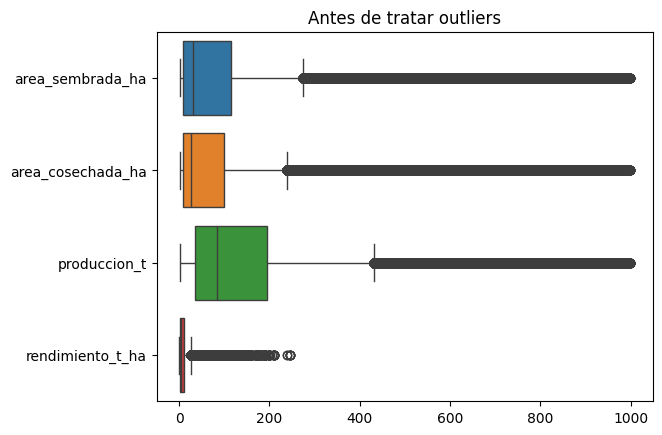

In [216]:
import seaborn as sns
import matplotlib.pyplot as plt

#Valores atipicos para las variables numéricas

# 1. Columnas numéricas
num_cols = ['area_sembrada_ha','area_cosechada_ha','produccion_t','rendimiento_t_ha']

# 2. Boxplots originales
sns.boxplot(data=datos[num_cols], orient='h')
plt.title('Antes de tratar outliers')
plt.show()



Las variables "area_sembrada_ha", "area_cosechada_ha" y "produccion_t" tienen muchos valores extremos que se alejan significativamente de la mediana, lo que indica posibles outliers que pueden distorsionar el análisis estadístico.

En "rendimiento_t_ha", aunque los valores son de menor magnitud comparados con las otras variables, también existen varios outliers visiblemente separados del resto de los datos.

El rango intercuartílico (la caja) es relativamente pequeño en comparación con el rango total de los datos, lo que resalta la alta concentración de datos cerca de la mediana y la dispersión producida por los outliers.

Los valores outliers no se eliminan del dataset debido a que son reales, son tomados de evaluaciones realizadas por el gobierno nacional lo cual permite indicar y medir la frecuencia de cultivos en Colombia, se evidencia que algunos lugares tienen mayor cantidad de cultivos, sin embargo, abundan cultivos pequeños (área sembrada por hectarea) a lo largo del pais. 


### Correcciones de Valores

No es necesario debido a que los valores están digitados correctamente, se realizó la limpieza de columnas de texto, dandoles formato de UPPERCASE y a los númericos para que la notación de "," se borrara y así el número entero fuera más fácil de leerlo. Todos los nombres de las columnas fueron formateados a LOWERCASE y en singular

### Agregación de Datos

In [225]:
datos_rend_cultivo = datos.groupby("cultivo")["rendimiento_t_ha"].mean().reset_index()
datos_rend_depto = datos.groupby("departamento")["rendimiento_t_ha"].mean().reset_index()
datos_rend_anual = datos.groupby(datos["anio"])["rendimiento_t_ha"]\
                   .mean().reset_index(name="Rendimiento_promedio")
datos_top10_cultivos = datos_rend_cultivo.sort_values(by="rendimiento_t_ha", ascending=False).head(10)
datos_top5_departamentos = datos_rend_depto.sort_values(by="rendimiento_t_ha", ascending=False).head(5)

C:\Users\sao22\AppData\Local\Temp\ipykernel_23416\1537879187.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos_rend_cultivo = datos.groupby("cultivo")["rendimiento_t_ha"].mean().reset_index()
C:\Users\sao22\AppData\Local\Temp\ipykernel_23416\1537879187.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos_rend_depto = datos.groupby("departamento")["rendimiento_t_ha"].mean().reset_index()


In [237]:
#Top 10 cultivos por rendimiento
print("La caña de azucar es el cultivo que mayor rendimiento tiene")
datos_top10_cultivos

La caña de azucar es el cultivo que mayor rendimiento tiene


,cultivo,rendimiento_t_ha
50,CAÑA AZUCARERA,117.301389
206,TOMATE,38.291158
61,CHAMPIÑON,34.181818
174,PIÑA,28.946936
194,SABILA,28.369622
133,MAIZ FORRAJERO,28.225983
60,CHAMBA,27.537500
57,CEBOLLIN,25.642857
78,CORDELINE CINTA,25.000000
98,FRESA,24.435326


In [256]:
#Departamentos con cultivo de caña azucarera

print("El departamento con mayor rendimineto en cultivos de caña de azucar es Risaralda,\nesto está relacionado a que es el departamento con mayor rendimiento por area cosechada en el país")

datos_dept_cana_azucar = datos[datos["cultivo"] == "CAÑA AZUCARERA"]\
    .groupby("departamento", observed=True)["rendimiento_t_ha"]\
    .mean().reset_index()

datos_dept_cana_azucar.sort_values(by="rendimiento_t_ha", ascending=False)



El departamento con mayor rendimineto en cultivos de caña de azucar es Risaralda,
esto está relacionado a que es el departamento con mayor rendimiento por area cosechada en el país


,departamento,rendimiento_t_ha
5,RISARALDA,124.423962
0,CALDAS,123.489592
6,VALLE DEL CAUCA,123.488764
4,QUINDIO,120.933333
1,CAUCA,106.507593
2,META,83.558333
3,NORTE DE SANTANDER,76.566579


In [234]:
#Primeros 5 departamentos con mayor rendimiento 
datos_top5_departamentos

,departamento,rendimiento_t_ha
24,RISARALDA,14.872112
29,VALLE DEL CAUCA,13.961407
6,CALDAS,11.795316
23,QUINDIO,11.588499
1,ANTIOQUIA,11.403534


In [236]:
#Rendimiento anual
print("Se observa que cada año el rendimiento de las hectareas cosechadas aumenta.")
datos_rend_anual

Se observa que cada año el rendimiento de las hectareas cosechadas aumenta.


,anio,Rendimiento_promedio
0,2006,8.032834
1,2007,8.757558
2,2008,8.872004
3,2009,9.088317
4,2010,9.053587
5,2011,8.874793
6,2012,9.145208
7,2013,9.285469
8,2014,9.182962
9,2015,9.268694


## Validación

1. Tras completar la limpieza y transformación del dataset EVA, se verificó que la estructura resultante conserva la información necesaria para responder a los objetivos iniciales del análisis. Las imputaciones aplicadas mantienen la completitud en variables críticas como el rendimiento, la estandarización de texto garantiza consistencia en categorías clave, y la corrección de formatos —especialmente la columna AÑO— asegura una granularidad adecuada para análisis temporales y comparativos.
Asimismo, se confirmaron la relevancia y vigencia de las variables después del procesamiento, y los outliers se preservaron por corresponder a datos reales propios de ciertos cultivos. Con estos ajustes, el dataset limpio continúa siendo apto para realizar análisis descriptivos, comparativos y tendencias, cumpliendo plenamente con los objetivos planteados. En caso de que futuros análisis requieran un nivel distinto de agregación, los datasets derivados creados permiten extender la exploración sin perder calidad analítica.

2. Una vez ejecutados los procesos de depuración y estandarización, se evaluó la capacidad del dataset transformado para sostener los objetivos analíticos definidos al inicio del proyecto. La revisión posterior confirmó que el conjunto de datos resultante mantiene la integridad semántica y estadística necesaria para responder a las preguntas de negocio planteadas.
En términos de completitud, la imputación basada en la mediana por cultivo permitió recuperar la funcionalidad analítica de la variable de rendimiento sin introducir sesgos significativos en la distribución original. Asimismo, la estandarización de campos textuales y la conversión de variables categóricas fortaleció la calidad referencial, permitiendo una segmentación y agrupación más robusta en niveles municipales, departamentales y por tipo de cultivo.
La granularidad del dataset resultó adecuada para análisis multiescalares, ya que conserva el nivel de detalle necesario (municipio–cultivo–año–periodo) sin comprometer la posibilidad de generar capas agregadas para estudios macro. La corrección rigurosa del campo AÑO "anio" garantizó la consistencia temporal indispensable para análisis de series y tendencias. Finalmente, la conservación de valores atípicos —previo análisis de su comportamiento y origen— respeta la variabilidad real del fenómeno agrícola y evita la distorsión de métricas críticas en cultivos con productividades naturalmente elevadas. En conjunto, estos ajustes aseguran que el dataset depurado sea metodológicamente sólido, analíticamente funcional y alineado con los objetivos de evaluación agropecuaria, permitiendo avanzar hacia modelos de análisis descriptivo y comparativo con un alto grado de confiabilidad.


## Link Trello

https://trello.com/invite/b/69128b59f7de381a8b44fedd/ATTI88ff843fbed32f438e79ee9e726b5fa84A1CD774/proyecto-integrado-iii-analisis-del-rendimiento-agricola-en-colombia